In [1]:
import numpy as np
np.__version__
print(np.__file__)

/ix1/ylee/Yifan_Zhang/envs/lib/python3.11/site-packages/numpy/__init__.py


In [2]:
import setuptools
setuptools.__file__

'/ix1/ylee/Yifan_Zhang/envs/lib/python3.11/site-packages/setuptools/__init__.py'

In [3]:
import squidpy as sq
import warnings
warnings.filterwarnings("ignore")

print(f"squidpy=={sq.__version__}")

# load the pre-processed dataset
adata = sq.datasets.slideseqv2()
adata

/ix1/ylee/Yifan_Zhang/envs/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/ix1/ylee/Yifan_Zhang/envs/lib/python3.11/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


squidpy==1.6.6


AnnData object with n_obs × n_vars = 41786 × 4000
    obs: 'barcode', 'x', 'y', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_MT', 'log1p_total_counts_MT', 'pct_counts_MT', 'n_counts', 'leiden', 'cluster'
    var: 'MT', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'spatial_neighbors', 'umap'
    obsm: 'X_pca', 'X_umap', 'deconvolution_results', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'spatial_connectivities', 'spatial_distances'

In [4]:
adata.obs['x']

AACGTCATAATCGT     888.95
TACTTTAGCGCAGT    4762.20
CATGCCTGGGTTCG     886.50
TCGATATGGCACAA    2237.10
TTATCTGACGAAGC    1031.80
                   ...   
CACCCGATGACTCC    4314.40
CTTGATTAGGCAGG    1452.50
GAGTTCCTAAGCGG    3090.10
GCGCTCAGTGCTCT    3304.10
GAGATAACAGTTCC    4902.30
Name: x, Length: 41786, dtype: float64

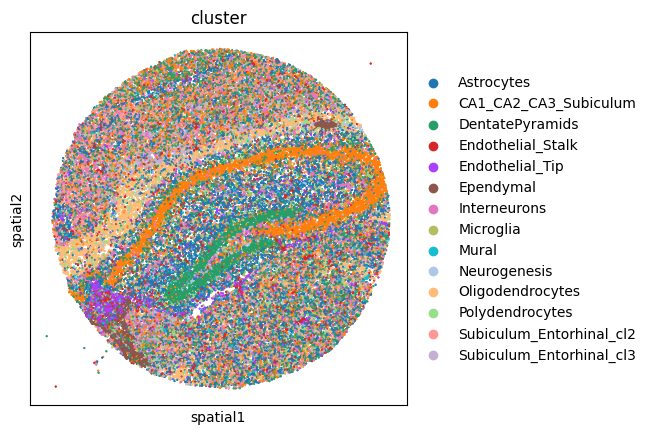

In [5]:
sq.pl.spatial_scatter(adata, color="cluster", size=1, shape=None)

In [6]:
import scanpy as sc
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

adata_ori = sc.read_h5ad('/ihome/ylee/yiz133/Code/Data processing/Lee experiments/E11S/E11S_annotated.h5ad') 

In [7]:
# Tell each cell which library it belongs to
# adata_ori.obs['library_id'] = library_id

NameError: name 'library_id' is not defined

In [ ]:
adata_ori

In [ ]:
adata_ori.obsm['spatial'] = adata_ori.obsm['X_spatial']
sq.pl.spatial_scatter(adata_ori, color="cell_type", size=1, shape=None)

In [ ]:
adata= adata_ori.copy()
adata

In [ ]:
sq.gr.spatial_neighbors(adata, n_rings=2, coord_type="grid", n_neighs=4)   # n=4 for square grid

In [ ]:
sq.gr.nhood_enrichment(adata, cluster_key="cell_type")

In [ ]:
adata.obsp["spatial_connectivities"]

In [ ]:
# Check the graph
print(adata.obsp['spatial_connectivities'].nnz)  # should be >> 0

# Check coordinate range
print(adata.obsm['spatial'].min(axis=0))
print(adata.obsm['spatial'].max(axis=0))

In [ ]:
sq.pl.nhood_enrichment(adata, cluster_key="cell_type")

### Ripley’s L statistic

In [ ]:
mode = "L"
sq.gr.ripley(adata, cluster_key="cell_type", mode=mode, max_dist=50)
sq.pl.ripley(adata, cluster_key="cell_type", mode=mode)

### LR

In [ ]:
# sq.gr.ligrec(
#     adata,
#     n_perms=10,
#     cluster_key="cell_type",
#     clusters=["Macrophage", "Neutrophil"],
#     use_raw=False
# )

# sq.pl.ligrec(
#     adata,
#     cluster_key="cell_type",
#     source_groups="Macrophage",
#     target_groups=["Neutrophil"],
#     pvalue_threshold=0.05,
#     swap_axes=True,
# )

### Spatially variable genes

In [ ]:
sq.gr.spatial_autocorr(adata, mode="moran")
adata.uns["moranI"].head(10)

In [ ]:
sq.pl.spatial_scatter(
    adata,
    shape=None,
    color=["Hspa1a", "Exd2", "Ppp1r15a", "Tshz3", "Qtrt1"],
    size=0.1,
    ncols = 2
)